GA1-RA1_spikes.mat
  n_detected=1902, waveform_len=74
  sr=32000.0 Hz, duration=7984.0 s
  timestamps_start=1711139561.8595219
  spike times (s): 5.071 – 7981.896

times_GA1-RA1.mat
  n_sorted=1887, unique clusters=[0 1]
    cluster 0: 57 spikes
    cluster 1: 1830 spikes
  rejected flags: 15 / 1902

GA1-RA1_spikeCodes.mat
  spikeHist: 2661322 bins @ ~3.00 ms, 2851 active bins


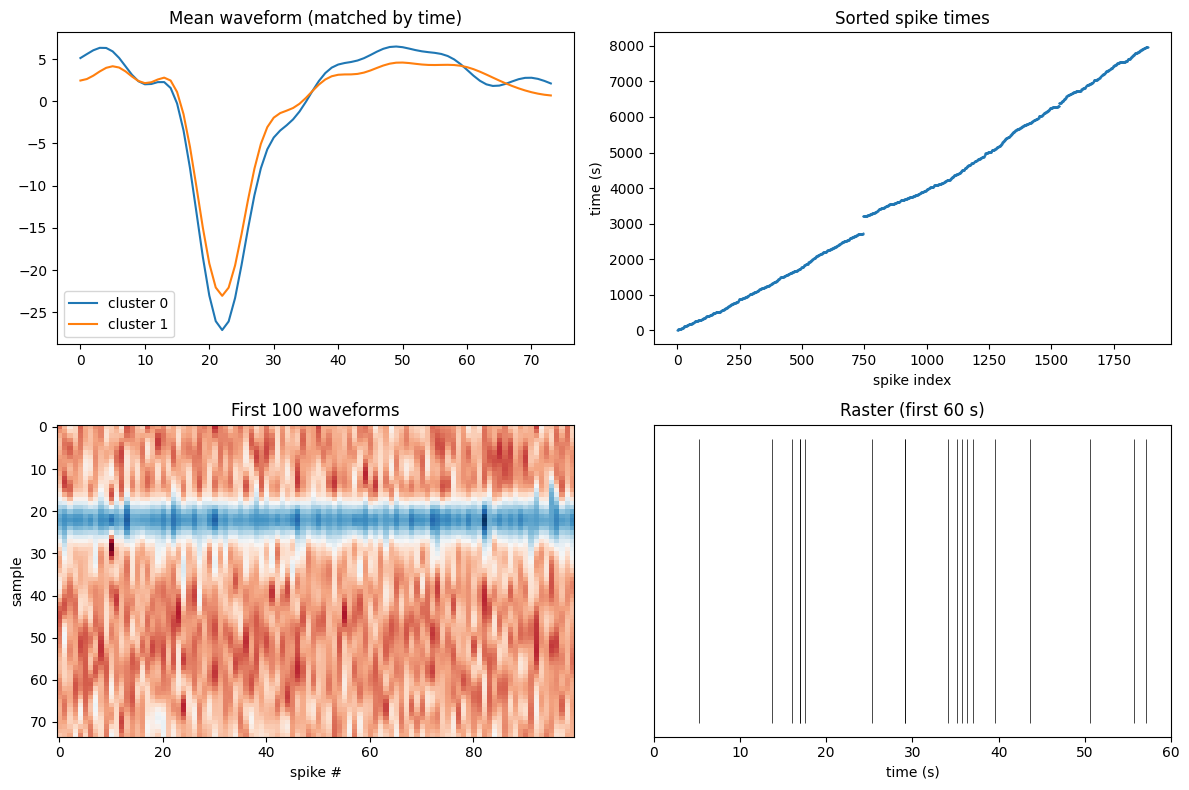

In [1]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(
    "/store/scratch/bsow/Documents/UCLA_24/data/ucla_data/572/"
    "Experiment-8-9-10-11/CSC_micro_spikes_removePLI-0_CAR-1_rejectNoiseSpikes-1"
)
CHANNEL = "GA1-RA1"

spikes_mat = DATA_DIR / f"{CHANNEL}_spikes.mat"
codes_mat = DATA_DIR / f"{CHANNEL}_spikeCodes.mat"
times_mat = DATA_DIR / f"times_{CHANNEL}.mat"

# --- spikes.mat ---
with h5py.File(spikes_mat, "r") as f:
    waveforms = f["spikes"][()]          # (74, n_detected)
    spike_times_s = f["spikeTimestamps"][()].ravel()
    timestamps_start = float(f["timestampsStart"][0, 0])  # Unix-ish session anchor
    sr = float(f["param/sr"][0, 0])
    duration_s = float(f["duration"][0, 0])

print(f"{CHANNEL}_spikes.mat")
print(f"  n_detected={waveforms.shape[1]}, waveform_len={waveforms.shape[0]}")
print(f"  sr={sr} Hz, duration={duration_s:.1f} s")
print(f"  timestamps_start={timestamps_start}")
print(f"  spike times (s): {spike_times_s.min():.3f} – {spike_times_s.max():.3f}")

# --- times.mat (sorted / classified spikes) ---
with h5py.File(times_mat, "r") as f:
    cluster_ids = f["cluster_class"][0, :].astype(int)
    sorted_times_s = f["cluster_class"][1, :].ravel()
    rejected = f["spikeIdxRejected"][()].astype(bool).ravel()

print(f"\ntimes_{CHANNEL}.mat")
print(f"  n_sorted={sorted_times_s.size}, unique clusters={np.unique(cluster_ids)}")
for cid in np.unique(cluster_ids):
    print(f"    cluster {cid}: {(cluster_ids == cid).sum()} spikes")
print(f"  rejected flags: {rejected.sum()} / {rejected.size}")

# --- spikeCodes.mat (binned raster) ---
with h5py.File(codes_mat, "r") as f:
  spike_hist = f["spikeHist"][()].ravel().astype(np.uint8)
  # spikeCodes is a MATLAB table; raw HDF5 value is an object reference, not useful in Python without mat73

bin_ms = duration_s * 1000.0 / spike_hist.size
print(f"\n{CHANNEL}_spikeCodes.mat")
print(f"  spikeHist: {spike_hist.size} bins @ ~{bin_ms:.2f} ms, {spike_hist.sum()} active bins")

# Quick plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mean waveforms per cluster (from times file)
for cid in np.unique(cluster_ids):
    idx = cluster_ids == cid
    # match sorted spike times to detected waveforms by timestamp
    t_clu = sorted_times_s[idx]
    cols = [np.argmin(np.abs(spike_times_s - t)) for t in t_clu[:200]]  # subsample for speed
    mean_wf = waveforms[:, cols].mean(axis=1)
    axes[0, 0].plot(mean_wf, label=f"cluster {cid}")
axes[0, 0].set_title("Mean waveform (matched by time)")
axes[0, 0].legend()

axes[0, 1].plot(sorted_times_s, ".", ms=1)
axes[0, 1].set_xlabel("spike index")
axes[0, 1].set_ylabel("time (s)")
axes[0, 1].set_title("Sorted spike times")

axes[1, 0].imshow(waveforms[:, :100], aspect="auto", cmap="RdBu_r")
axes[1, 0].set_title("First 100 waveforms")
axes[1, 0].set_xlabel("spike #")
axes[1, 0].set_ylabel("sample")

win_s = 60.0
t0 = sorted_times_s.min()
mask = (sorted_times_s >= t0) & (sorted_times_s < t0 + win_s)
axes[1, 1].vlines(sorted_times_s[mask] - t0, 0, 1, color="k", linewidth=0.5)
axes[1, 1].set_xlim(0, win_s)
axes[1, 1].set_title(f"Raster (first {win_s:.0f} s)")
axes[1, 1].set_xlabel("time (s)")
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
"""
Updated feature extraction for 24_S06E01 (paper-aligned where possible)
- Biphone surprisal currently disabled
- Uses Hilbert + Butterworth envelope pipeline
- Uses torchcrepe pitch pipeline with 100 ms smoothing
- Uses wordfreq Zipf scores for word frequency
"""

from bisect import bisect_right
from collections import Counter
from pathlib import Path
import re

import torch
try:
    import torchcrepe
except ImportError as exc:
    raise ImportError(
        "torchcrepe is required for pitch extraction. Install it in your env (e.g., `uv pip install torchcrepe`)."
    ) from exc

import librosa
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, hilbert
from wordfreq import zipf_frequency

# Paths
phoneme_csv = Path('/store/scratch/bsow/Documents/UCLA_24/data/24_S06E01_phonemes.csv')
word_csv = Path('/store/scratch/bsow/Documents/UCLA_24/data/24_S06E01_words.csv')
srt_path = Path('/store/scratch/bsow/Documents/UCLA_24/data/24_S06E01.srt')
audio_path = Path('/store/scratch/bsow/Documents/UCLA_24/data/24_S06E01.wav')
out_csv = Path('/store/scratch/bsow/Documents/UCLA_24/data/24_S06E01_events_vowel_word_features.csv')

# Audio constants
TARGET_SR = 16_000
HOP_MS = 10
WINDOW_MS = 100
HOP_SAMPLES = int(HOP_MS / 1000 * TARGET_SR)
N_FFT = int(WINDOW_MS / 1000 * TARGET_SR)
N_MELS = 16
ENV_BANDPASS_LOW_HZ = 1.0
ENV_BANDPASS_HIGH_HZ = 10.0
PITCH_SMOOTH_MS = 100
CREPE_CONF_THRESHOLD = 0.5


def srt_time_to_seconds(ts: str) -> float:
    hh, mm, rest = ts.split(':')
    ss, ms = rest.split(',')
    return int(hh) * 3600 + int(mm) * 60 + int(ss) + int(ms) / 1000.0


def parse_srt(file_path: Path) -> pd.DataFrame:
    txt = file_path.read_text(encoding='utf-8')
    blocks = [b.strip() for b in txt.split('\n\n') if b.strip()]
    rows = []
    for block in blocks:
        lines = block.splitlines()
        if len(lines) < 3 or '-->' not in lines[1]:
            continue
        start_txt, end_txt = [x.strip() for x in lines[1].split('-->')]
        rows.append(
            {
                'start': srt_time_to_seconds(start_txt),
                'end': srt_time_to_seconds(end_txt),
                'text': ' '.join(lines[2:]).strip(),
            }
        )
    return pd.DataFrame(rows).sort_values('start').reset_index(drop=True)


def normalize_token(x: str) -> str:
    return re.sub(r"[^\w']+", '', str(x).lower())


def minmax01(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    finite = np.isfinite(x)
    out = np.zeros_like(x)
    if finite.any():
        lo, hi = np.nanmin(x[finite]), np.nanmax(x[finite])
        out[finite] = (x[finite] - lo) / (hi - lo + 1e-8)
    return out


def onset_and_duration(
    series: pd.Series,
    is_valid,
    frame_time: np.ndarray,
    frame_dt: float,
) -> tuple[pd.Series, pd.Series]:
    onset_label = pd.Series('', index=series.index, dtype=object)
    onset_duration = pd.Series(0.0, index=series.index, dtype=float)
    n = len(series)
    i = 0
    while i < n:
        label = series.iat[i]
        if not is_valid(label):
            i += 1
            continue
        j = i
        while j + 1 < n and series.iat[j + 1] == label:
            j += 1
        onset_label.iat[i] = str(label)
        onset_duration.iat[i] = float((frame_time[j] + frame_dt) - frame_time[i])
        i = j + 1
    return onset_label, onset_duration


def align(source_values: np.ndarray, source_times: np.ndarray, target_times: np.ndarray) -> np.ndarray:
    source_values = np.asarray(source_values, dtype=float)
    source_times = np.asarray(source_times, dtype=float)
    target_times = np.asarray(target_times, dtype=float)

    if source_values.ndim != 1 or source_times.ndim != 1 or target_times.ndim != 1:
        raise ValueError('align expects 1-D arrays')
    if len(source_values) != len(source_times):
        raise ValueError('source_values and source_times must have the same length')
    if len(source_values) == 0 or len(target_times) == 0:
        return np.zeros(len(target_times), dtype=float)
    if np.any(np.diff(source_times) < 0) or np.any(np.diff(target_times) < 0):
        raise ValueError('source_times and target_times must be monotonic non-decreasing')

    n_target = len(target_times)
    out = np.zeros(n_target, dtype=float)

    frame_dt_target = float(np.median(np.diff(target_times))) if n_target > 1 else 0.0
    edges = np.empty(n_target + 1)
    if n_target > 1:
        edges[1:-1] = 0.5 * (target_times[:-1] + target_times[1:])
        edges[0] = target_times[0] - 0.5 * frame_dt_target
        edges[-1] = target_times[-1] + 0.5 * frame_dt_target
    else:
        edges[0] = target_times[0] - 0.5
        edges[-1] = target_times[0] + 0.5

    bin_idx = np.searchsorted(edges, source_times, side='right') - 1
    counts = np.zeros(n_target, dtype=float)

    for src_i, b in enumerate(bin_idx):
        if 0 <= b < n_target:
            out[b] += source_values[src_i]
            counts[b] += 1.0

    empty = counts == 0
    if empty.any():
        out[empty] = np.interp(
            target_times[empty], source_times, source_values,
            left=float(source_values[0]), right=float(source_values[-1])
        )
        counts[empty] = 1.0

    out /= counts
    return out


# Load tabular data
phon = pd.read_csv(phoneme_csv)
words = pd.read_csv(word_csv)
subs = parse_srt(srt_path)

if len(phon) != len(words):
    raise ValueError(f'Row mismatch: phonemes={len(phon)}, words={len(words)}')
if not np.allclose(phon['time'].to_numpy(), words['time'].to_numpy()):
    raise ValueError('Time columns not aligned between phoneme and word CSVs.')

frame_time = phon['time'].to_numpy(dtype=float)
frame_dt = float(np.median(np.diff(frame_time)))

phoneme_cols = [c for c in phon.columns if c not in ('frame', 'time')]
frame_phoneme = phon[phoneme_cols].idxmax(axis=1)

vowel_chars = set('aeiouAEIOUæɑɒɔəɛɜɪʊʉɐɚ')
diphthongs = {'aj', 'aw', 'ej', 'ow', 'əw', 'ɔj'}
non_speech_tokens = {'sil', 'spn'}
vowel_labels = {
    ph for ph in phoneme_cols
    if (ph in diphthongs or any(ch in vowel_chars for ch in ph)) and ph not in non_speech_tokens
}

# Section 1 — onsets and lexical/prosodic tabular features
is_valid_vowel = lambda x: isinstance(x, str) and x in vowel_labels
vowel_onset, vowel_duration = onset_and_duration(frame_phoneme, is_valid_vowel, frame_time, frame_dt)

is_valid_phoneme = lambda x: isinstance(x, str) and x not in non_speech_tokens and x != ''
phoneme_onset, phoneme_duration = onset_and_duration(frame_phoneme, is_valid_phoneme, frame_time, frame_dt)

word_series = words['word']
is_valid_word = lambda x: not pd.isna(x) and str(x).strip().lower() not in {'none', ''}
word_onset, word_duration = onset_and_duration(word_series, is_valid_word, frame_time, frame_dt)

word_onset_mask = word_onset != ''
onset_rows = word_onset[word_onset_mask].index.to_numpy()
onset_words = word_onset[word_onset_mask].astype(str)

word_frequency = pd.Series(0.0, index=word_series.index, dtype=float)
for idx, token in onset_words.items():
    word_frequency.iat[idx] = float(zipf_frequency(token, 'en'))

word_char_len = pd.Series(0.0, index=word_series.index, dtype=float)
for idx in onset_rows:
    word_char_len.iat[idx] = len(str(word_onset.iat[idx]).strip())

pause_duration_ms = pd.Series(0.0, index=word_series.index, dtype=float)
for prev_idx, curr_idx in zip(onset_rows[:-1], onset_rows[1:]):
    prev_end = frame_time[prev_idx] + float(word_duration.iat[prev_idx])
    gap_ms = max(0.0, frame_time[curr_idx] - prev_end) * 1000.0
    pause_duration_ms.iat[curr_idx] = gap_ms

word_ner = pd.Series('', index=word_series.index, dtype=object)
try:
    import spacy
    ner_nlp = spacy.load('en_core_web_sm')
    subtitle_entities = []
    for text in subs['text'].tolist():
        doc = ner_nlp(text)
        token_to_label = {}
        for ent in doc.ents:
            for tok in ent:
                key = normalize_token(tok.text)
                if key and key not in token_to_label:
                    token_to_label[key] = ent.label_
        subtitle_entities.append(token_to_label)

    sub_starts = subs['start'].to_numpy(dtype=float)
    sub_ends = subs['end'].to_numpy(dtype=float)
    for idx in onset_rows:
        t = float(frame_time[idx])
        token = normalize_token(onset_words.loc[idx])
        if not token:
            continue
        sub_i = bisect_right(sub_starts, t) - 1
        if sub_i < 0 or sub_i >= len(subs):
            continue
        if not (sub_starts[sub_i] <= t <= sub_ends[sub_i]):
            continue
        word_ner.iat[idx] = subtitle_entities[sub_i].get(token, '')
except Exception as exc:
    print(f'NER skipped: {exc}')

# Biphone surprisal disabled for now.
# Keep the column with zeros so downstream code/schema stays stable.
biphone_surprisal = pd.Series(0.0, index=phon.index, dtype=float)
print('Biphone surprisal disabled: column set to 0.0 for all rows.')


# Section 2 — audio features
print(f'Loading audio: {audio_path}')
y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
print(f'  Duration: {len(y)/sr:.1f}s  SR: {sr}Hz')

# Mel spectrogram
mel_power = librosa.feature.melspectrogram(
    y=y, sr=sr,
    n_fft=N_FFT, hop_length=HOP_SAMPLES,
    n_mels=N_MELS, fmin=0, fmax=8000, power=2.0,
)
mel_db = librosa.power_to_db(mel_power, ref=np.max)

mel_aligned = {}
for i in range(N_MELS):
    band_norm = minmax01(mel_db[i])
    band_times = librosa.times_like(band_norm, sr=TARGET_SR, hop_length=HOP_SAMPLES)
    mel_aligned[f'mel_{i:02d}'] = align(band_norm, band_times, frame_time)

# Continuous envelope (paper-style): Hilbert magnitude -> 100 Hz -> 3rd-order Butterworth 1-10 Hz band-pass
analytic = hilbert(y)
env_cont = np.abs(analytic)
env_100 = env_cont[::HOP_SAMPLES]

env_fs = TARGET_SR / HOP_SAMPLES  # 100 Hz
nyq = 0.5 * env_fs
low = max(0.01, min(ENV_BANDPASS_LOW_HZ, nyq * 0.95))
high = max(low + 0.01, min(ENV_BANDPASS_HIGH_HZ, nyq * 0.99))
b, a = butter(3, [low / nyq, high / nyq], btype='band')
env_band = filtfilt(b, a, env_100)
env_norm = minmax01(env_band)
env_times = np.arange(len(env_norm), dtype=float) / env_fs
env_aligned = align(env_norm, env_times, frame_time)

# Envelope peak rate from local peaks in derivative (no thresholding; keep peak magnitudes)
env_d = np.gradient(env_norm)
peaks, _ = find_peaks(env_d)
rate_sparse = np.zeros_like(env_norm)
rate_sparse[peaks] = env_d[peaks]
rate_times = env_times
env_peak_rate_aligned = align(rate_sparse, rate_times, frame_time)

# Pitch via torchcrepe
# torchcrepe operates on torch tensors and returns frame-wise F0 at hop_length steps.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
audio_t = torch.tensor(y, dtype=torch.float32, device=device).unsqueeze(0)

pitch_t, periodicity_t = torchcrepe.predict(
    audio_t,
    sr,
    HOP_SAMPLES,
    fmin=50,
    fmax=500,
    model='full',
    batch_size=1024,
    device=device,
    decoder=torchcrepe.decode.viterbi,
    return_periodicity=True,
)

pitch_hz = pitch_t.squeeze(0).detach().cpu().numpy().astype(float)
confidence = periodicity_t.squeeze(0).detach().cpu().numpy().astype(float)
pitch_hz[confidence < CREPE_CONF_THRESHOLD] = 0.0

pitch_win = max(1, int(round(PITCH_SMOOTH_MS / HOP_MS)))
pitch_smooth = np.convolve(pitch_hz, np.ones(pitch_win) / pitch_win, mode='same')

voiced_vals = pitch_smooth[pitch_smooth > 0]
if len(voiced_vals) > 0:
    lo5, hi95 = np.percentile(voiced_vals, 5), np.percentile(voiced_vals, 95)
    pitch_clipped = np.clip(pitch_smooth, lo5, hi95)
    pitch_clipped[pitch_smooth == 0] = 0.0
    pitch_norm = minmax01(pitch_clipped)
else:
    pitch_norm = np.zeros_like(pitch_smooth)

pitch_deriv = np.gradient(pitch_norm)
pitch_up = np.maximum(pitch_deriv, 0.0)
pitch_down = np.maximum(-pitch_deriv, 0.0)

pitch_times = np.arange(len(pitch_smooth), dtype=float) * (HOP_SAMPLES / sr)
pitch_hz_aligned = align(pitch_smooth, pitch_times, frame_time)
pitch_norm_aligned = align(pitch_norm, pitch_times, frame_time)
pitch_up_aligned = align(pitch_up, pitch_times, frame_time)
pitch_down_aligned = align(pitch_down, pitch_times, frame_time)

print('\nFeature lengths before alignment:')
print(f'  env_norm:   {len(env_norm)}')
print(f'  pitch_hz:   {len(pitch_smooth)}')
print(f'  mel band 0: {mel_db.shape[1]}')
print(f'  frame_time: {len(frame_time)}')


# Assemble output
out = pd.DataFrame(
    {
        'frame': phon['frame'],
        'time': phon['time'],
        'vowel_onset': vowel_onset,
        'vowel_duration': vowel_duration,
        'phoneme_onset': phoneme_onset,
        'phoneme_duration': phoneme_duration,
        'word_onset': word_onset,
        'word_duration': word_duration,
        'word_frequency': word_frequency,
        'word_char_len': word_char_len,
        'word_ner': word_ner,
        'pause_duration_ms': pause_duration_ms,
        'biphone_surprisal': biphone_surprisal,
        'env': env_aligned,
        'env_peqqak_rate': env_peak_rate_aligned,
        'pitch_hz': pitch_hz_aligned,
        'pitch_norm': pitch_norm_aligned,
        'pitch_up': pitch_up_aligned,
        'pitch_down': pitch_down_aligned,
    }
)

for k, v in mel_aligned.items():
    out[k] = v

out.to_csv(out_csv, index=False)

print(f'\nSaved: {out_csv}')
print(f'Rows:              {len(out)}')
print(f'Vowel onsets:      {(out["vowel_onset"] != "").sum()}')
print(f'Phoneme onsets:    {(out["phoneme_onset"] != "").sum()}')
print(f'Word onsets:       {(out["word_onset"] != "").sum()}')
print(f'Word freq onsets:  {(out["word_frequency"] > 0).sum()}')
print(f'Word NER onsets:   {(out["word_ner"] != "").sum()}')
print(f'Biphone rows > 0:  {(out["biphone_surprisal"] > 0).sum()}')
print(f'Mel bands:         {len(mel_aligned)}')
print(f'Total columns:     {len(out.columns)}')

/store/scratch/bsow/Documents/UCLA_24/.venv/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Biphone surprisal disabled: column set to 0.0 for all rows.
Loading audio: /store/scratch/bsow/Documents/UCLA_24/data/24_S06E01.wav


/store/scratch/bsow/Documents/UCLA_24/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Duration: 2479.4s  SR: 16000Hz
